In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

import specula
specula.init(-1)

from specula import cpuArray
from specula.data_objects.iir_filter_data import IirFilterData
from specula.mmlib.utils import get_pupil_mask, read_freq, get_psd
from error_budget import AOErrorBudgetMachine

import os
root_dir = '/raid1/mmenessini/calibration/SOUL'
main_config = 'soul_main.yml'

Cupy import successfull. Installed version is: 14.0.1
Default device is CPU
Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0


In [2]:
soul = AOErrorBudgetMachine(base_path=root_dir, telescope_diameter=8.4, xp=specula.xp)
controller = IirFilterData.from_gain_and_ff(gain=[0.5],ff=[0.9])#gain=[0.55,0.45,0.40,0.35],ff=[1.0,0.999996,0.999365,0.977895])

soul.set_control_parameters(controller=controller, delay_frames=2.0)
soul.set_detector_parameters(RON=0.4, F_excess=np.sqrt(2))

In [3]:
soul.fitting_error(r0=10e-2,n_modes=660)

array(90.66247222)

In [9]:
soul.servo_lag_error(r0=10e-2,fs=1700,V=10,mode_id=0)



array(21075.82102312)

0.00013258758314689921 2.107582102312489e-05 1.598754871733914e-08


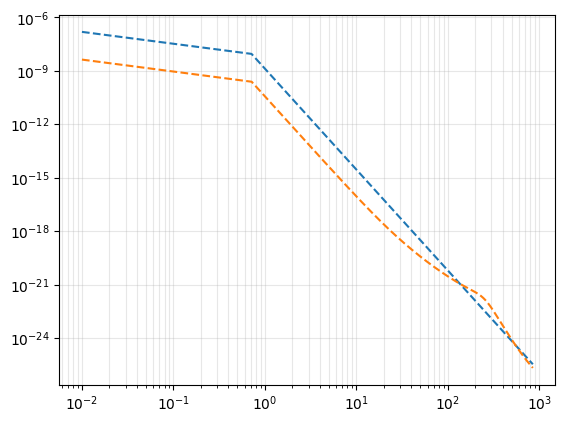

In [22]:
rtf = soul.get_rtf(mode=0,fs=1700)
ntf = soul.get_ntf(mode=0,fs=1700)
freq = soul.get_freq_vec(fs=1700)
psd = soul.analytical_atmo_psd(mode_id=0, r0=10e-2, V=10, freq=freq)

plt.figure()
# plt.loglog(cpuArray(freq),cpuArray(rtf**2),'--')
plt.loglog(cpuArray(freq),cpuArray(psd),'--')
plt.loglog(cpuArray(freq),cpuArray(psd*rtf**2),'--')
plt.grid(which='both',alpha=0.3)

from scipy.integrate import simpson
from specula.mmlib.utils import von_karman_power
vkp = simpson(np.sqrt(cpuArray(psd)),cpuArray(freq))
filt = simpson(cpuArray(psd*rtf**2),cpuArray(freq))

print(vkp,np.sqrt(filt),von_karman_power(1/8.4,r0=10e-2,L0=25,D=8.4)*((500e-9)*(2*np.pi))**2)

In [5]:
raise ValueError('Stop')

ValueError: Stop

[0. 0. 0. 0. 0.]
[0.50614051 0.62527138 0.77594036 0.90731335 0.92993945]


Text(0.5, 1.0, 'Fraction of light inside the pupils')

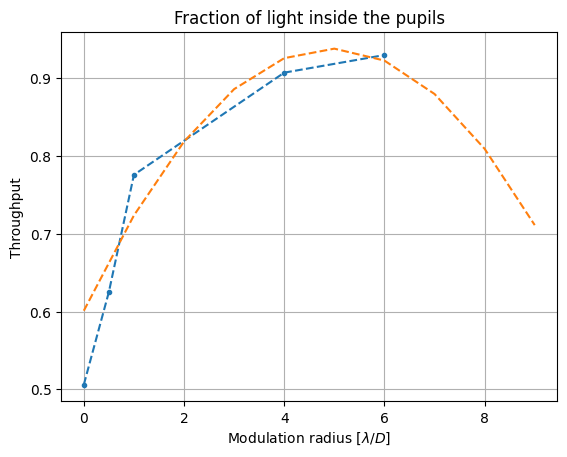

In [ ]:
rMods = np.array([0,0.5,1,4,6])
thrp = np.zeros(len(rMods))
root_dir2 = '/raid1/mmenessini/calibration/XAO'
print(thrp)
for k,rMod in enumerate(rMods):
    thrp[k] = float(fits.getdata(os.path.join(root_dir2,'slopenulls',f'pyr{rMod:1.1f}_48x48_throughput.fits'))[0])
print(thrp)

p = np.polyfit(rMods[1:],thrp[1:],2)


plt.figure()
plt.plot(rMods,thrp,'--.')
# plt.plot(rMods,thrp[0],'--')
plt.grid()
plt.xlabel(r'Modulation radius [$\lambda/D$]')
plt.ylabel('Throughput')
plt.title('Fraction of light inside the pupils')

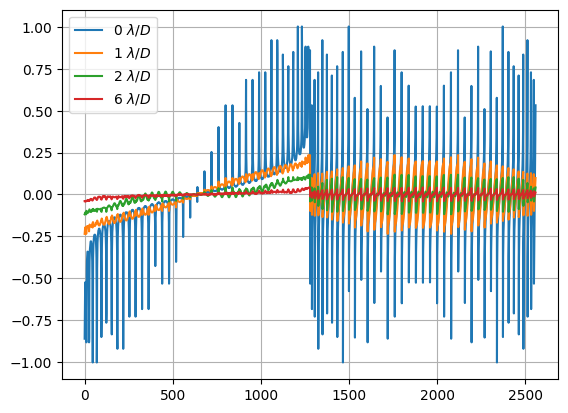

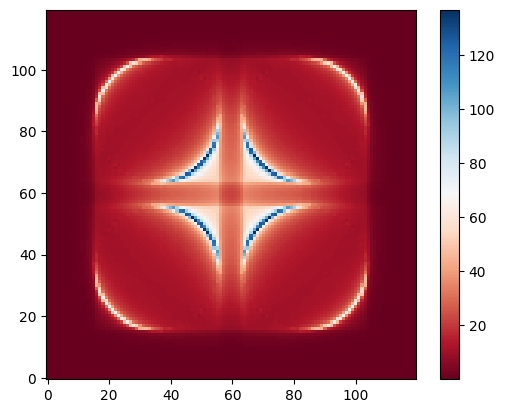

In [ ]:
pyr_mask = get_pupil_mask(npix=120,filepath=os.path.join(root_dir,'pupils/pyr_pupdata_40x40.fits'))

frame = fits.getdata(os.path.join(root_dir, 'frames/pyr0.0_40x40_frame_null.fits'))[0]

sn0 = fits.getdata(os.path.join(root_dir, 'slopenulls/pyr0.0_40x40_sn.fits'))
sn1 = fits.getdata(os.path.join(root_dir, 'slopenulls/pyr1.0_40x40_sn.fits'))
sn2 = fits.getdata(os.path.join(root_dir, 'slopenulls/pyr2.0_40x40_sn.fits'))
sn6 = fits.getdata(os.path.join(root_dir, 'slopenulls/pyr6.0_40x40_sn.fits'))

thrp = np.sum(frame[pyr_mask])/np.sum(frame)

# sn /= np.sum(abs(sn))
# sn_ri /= np.sum(abs(sn_ri))/thrp
n_subaps = np.sum(pyr_mask)/4

plt.figure()
plt.plot(sn0,label=r'0 $\lambda/D$')
plt.plot(sn1,label=r'1 $\lambda/D$')
plt.plot(sn2,label=r'2 $\lambda/D$')
plt.plot(sn6,label=r'6 $\lambda/D$')
plt.legend()
plt.grid()

plt.figure()
plt.imshow(frame,cmap='RdBu',origin='lower')
plt.colorbar()

In [ ]:
aliaspath = os.path.join(root_dir,'aliasing')
os.makedirs(aliaspath,exist_ok=True)
fs = read_freq(params_path=f'./{main_config}')

alias_modes = fits.getdata(os.path.join(root_dir,'scratch_aliasing','pyr_modes.fits'))
psd,f = get_psd(alias_modes.T, nperseg=1024, dt=1/fs)
tag = f'pyr_modes_alias_PSD'
fits.writeto(os.path.join(aliaspath,tag+'.fits'),psd,overwrite=True)
print('Saved aliasing PSD as: '+tag)

atmo_modes = fits.getdata(os.path.join(root_dir,'scratch_aliasing','atmo_res.fits'))
atmo_psd,atmo_f = get_psd(atmo_modes.T, nperseg=1024, dt=1/fs)

print(psd.shape,f.shape)

Saved aliasing PSD as: pyr_modes_alias_PSD
(54, 513) (513,)


(np.float64(1.6608205782312926), np.float64(850.3401360544218))

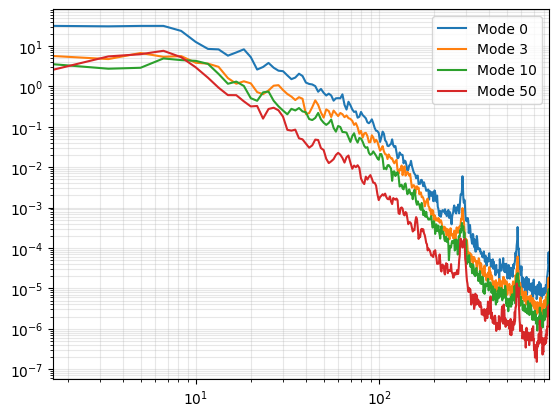

In [ ]:
plt.figure()
for mode in np.array([0,3,10,50]):
    plt.loglog(f,psd[mode],label=f'Mode {mode}')
plt.legend()
plt.grid(which='both',alpha=0.3)
plt.xlim([f[1],f[-1]])

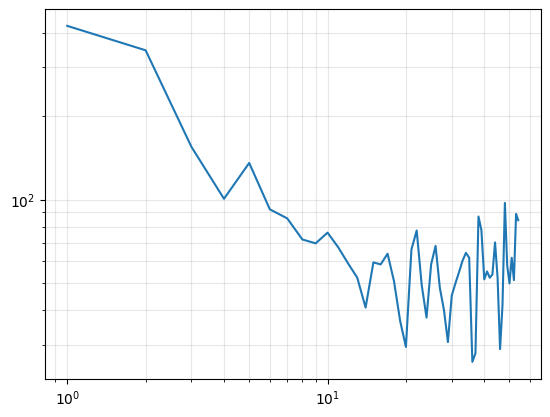

In [ ]:
from scipy.integrate import simpson

alias = simpson(psd,f)

x = np.arange(len(alias))+1

plt.figure()
plt.loglog(x,alias)
plt.grid(which='both',alpha=0.3)

(np.float64(1.6608205782312926), np.float64(850.3401360544218))

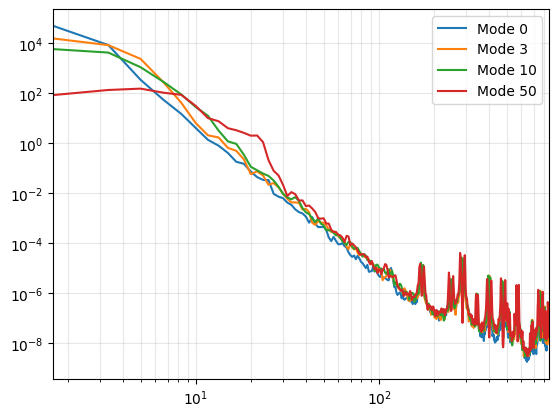

In [ ]:
plt.figure()
for mode in np.array([0,3,10,50]):
    plt.loglog(atmo_f,atmo_psd[mode],label=f'Mode {mode}')
plt.legend()
plt.grid(which='both',alpha=0.3)
plt.xlim([f[1],f[-1]])

In [ ]:
def rec_ron_covariance(rMod:float,n_modes:int,n_subaps:int):
    rec = fits.getdata(os.path.join(root_dir, 'rec', f'pyr{rMod:1.1f}_{n_subaps:1.0f}x{n_subaps:1.0f}_{n_modes:1.0f}modes_rec.fits'))
    frame = fits.getdata(os.path.join(root_dir, 'frames', f'pyr{rMod:1.1f}_{n_subaps:1.0f}x{n_subaps:1.0f}_frame_null.fits'))[0]
    pyr_mask = get_pupil_mask(npix=120,filepath=os.path.join(root_dir,f'pupils/pyr_pupdata_{n_subaps:1.0f}x{n_subaps:1.0f}.fits'))
    flux = np.sum(frame)
    norm = np.mean(frame[pyr_mask.astype(bool)])/4
    norm_rec = rec / (norm / flux)
    rec_cov = norm_rec @ norm_rec.T
    return np.diag(rec_cov)

def rec_shot_covariance(rMod:float,n_modes:int,n_subaps:int):
    rec = fits.getdata(os.path.join(root_dir, 'rec', f'pyr{rMod:1.1f}_{n_subaps:1.0f}x{n_subaps:1.0f}_{n_modes:1.0f}modes_rec.fits'))
    frame = fits.getdata(os.path.join(root_dir, 'frames', f'pyr{rMod:1.1f}_{n_subaps:1.0f}x{n_subaps:1.0f}_frame_null.fits'))[0]
    # sn = fits.getdata(os.path.join(root_dir, 'slopenulls', f'pyr{rMod:1.1f}_{n_subaps:1.0f}x{n_subaps:1.0f}_sn.fits'))
    pyr_mask = get_pupil_mask(npix=120,filepath=os.path.join(root_dir,f'pupils/pyr_pupdata_{n_subaps:1.0f}x{n_subaps:1.0f}.fits'))
    flux = np.sum(frame)
    sn = frame[pyr_mask.astype(bool)] 
    norm = np.mean(sn)/4
    norm_rec = rec / (norm / flux)
    if np.shape(rec)[1] != len(sn): # slopes were used
        weights = np.array([[1,1,-1,-1],[-1,1,1,-1]])**2
        sn = sn.reshape(-1,4) @ weights.T
    phot_noise = np.diag(sn.flatten()/flux**2)
    rec_cov = norm_rec @ phot_noise @ norm_rec.T
    return np.diag(rec_cov)

# def rec_phot_cov(rec,frame,mask,sn,flux=None):
#     if flux is None:
#         flux = np.sum(frame)
#     norm = np.mean(frame[mask.astype(bool)])
#     phot_noise = np.diag(sn/ (norm / flux))
#     rec_cov = rec @ phot_noise @ rec.T
#     return np.diag(rec_cov)

ValueError: x and y must have same first dimension, but have shapes (54,) and (660,)

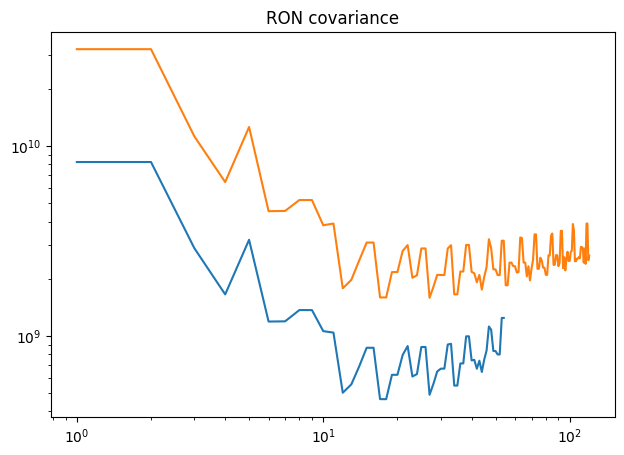

In [ ]:

rec0_ron_cov = rec_ron_covariance(rMod=0.0,n_modes=660,n_subaps=40) 
rec1_ron_cov = rec_ron_covariance(rMod=1.0,n_modes=660,n_subaps=40) 
rec2_10x10_ron_cov = rec_ron_covariance(rMod=2.0,n_modes=54,n_subaps=10) 
rec2_20x20_ron_cov = rec_ron_covariance(rMod=2.0,n_modes=120,n_subaps=20) 
rec2_ron_cov = rec_ron_covariance(rMod=2.0,n_modes=660,n_subaps=40) 
rec4_ron_cov = rec_ron_covariance(rMod=4.0,n_modes=660,n_subaps=40) 
rec6_ron_cov = rec_ron_covariance(rMod=6.0,n_modes=660,n_subaps=40) 

rec0_shot_cov = rec_shot_covariance(rMod=0.0,n_modes=660,n_subaps=40) 
rec1_shot_cov = rec_shot_covariance(rMod=1.0,n_modes=660,n_subaps=40) 
rec2_10x10_shot_cov = rec_shot_covariance(rMod=2.0,n_modes=54,n_subaps=10) 
rec2_20x20_shot_cov = rec_shot_covariance(rMod=2.0,n_modes=120,n_subaps=20) 
rec2_shot_cov = rec_shot_covariance(rMod=2.0,n_modes=660,n_subaps=40) 
rec4_shot_cov = rec_shot_covariance(rMod=4.0,n_modes=660,n_subaps=40) 
rec6_ron_cov = rec_ron_covariance(rMod=6.0,n_modes=660,n_subaps=40) 

x10 = np.arange(54)+1
x20 = np.arange(120)+1
x40 = np.arange(660)+1

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.title('RON covariance')
plt.loglog(x10,rec2_10x10_ron_cov,label=r'2 $\lambda/D$ (10x10)')
plt.loglog(x20,rec2_20x20_ron_cov,label=r'2 $\lambda/D$ (20x20)')
plt.loglog(x,rec0_ron_cov,label=r'0 $\lambda/D$')
# plt.loglog(x,rec1_ron_cov,label=r'1 $\lambda/D$')
plt.loglog(x,rec2_ron_cov,label=r'2 $\lambda/D$')
plt.loglog(x,rec4_ron_cov,label=r'4 $\lambda/D$')
plt.loglog(x,rec6_ron_cov,label=r'6 $\lambda/D$')
plt.legend()
plt.grid(which='both',alpha=0.3)
plt.subplot(1,2,2)
plt.title('Shot noise covariance')
plt.loglog(x10,rec2_10x10_shot_cov,label=r'2 $\lambda/D$ (10x10)')
plt.loglog(x20,rec2_20x20_shot_cov,label=r'2 $\lambda/D$ (20x20)')
plt.loglog(x,rec0_shot_cov,label=r'0 $\lambda/D$')
# plt.loglog(x,rec1_shot_cov,label=r'1 $\lambda/D$')
plt.loglog(x,rec2_shot_cov,label=r'2 $\lambda/D$')
plt.loglog(x,rec4_shot_cov,label=r'4 $\lambda/D$')
# plt.loglog(x,rec6_ron_cov,label=r'6 $\lambda/D$')
plt.legend()
plt.grid(which='both',alpha=0.3)

In [ ]:
def n_photons(mag, diameter, fs, thrp = 1.0, obsratio=0.0):
    B0 = 1e+10 # ph/m^2/s
    area = np.pi/4*(diameter**2-(obsratio*diameter)**2)
    flux = B0*10**(-mag/2.5) # ph/m^2/s
    n_phot = flux * area / fs * thrp
    return n_phot

def compute_slope_noise_variance(sn_ri, D:float, mag:float, fs:float,
                                F_excess:float=1.0, RON:float=0.5, slopes_from_intensity:bool=False,
                                sky_bkg:float=0.0, dark_curr:float=0.0):

    n_subaps = int(len(sn_ri)/4)
    n_phot = n_photons(mag, D, fs)
    phot_per_pix = sn_ri*n_phot/n_subaps/4
    pixel_variance = F_excess ** 2 * (phot_per_pix + sky_bkg + dark_curr) + RON

    if slopes_from_intensity is False:
        weights = np.array([[1,1,-1,-1],[-1,1,1,-1]])
        pixel_variance = pixel_variance.reshape([4,n_subaps])
        slope_variance = weights**2 @ pixel_variance / (4*n_phot) ** 2   
    else:
        slope_variance = pixel_variance / n_phot ** 2 
                                         
    return slope_variance.flatten()

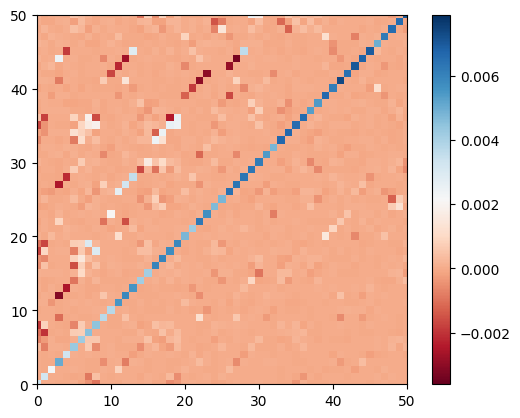

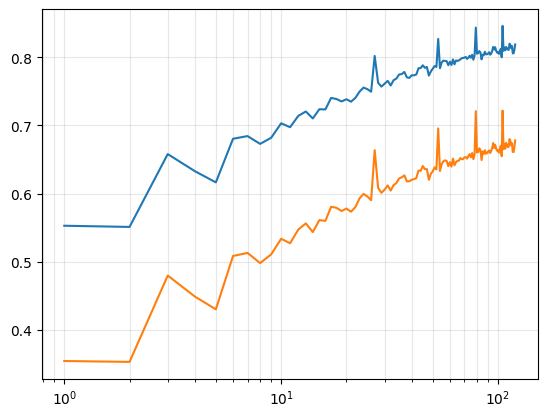

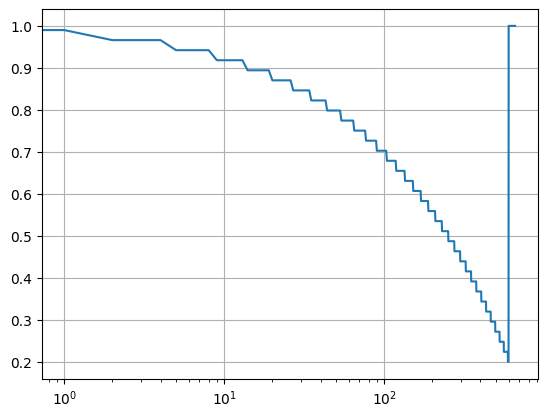

In [ ]:
def compute_optical_gain(IM, IMpc):
    norm = np.diag(IM.T @ IM)
    return np.diag(IMpc.T @ IM)/norm

im = fits.getdata(os.path.join(root_dir, 'im/pyr0.0_20x20_im.fits'))[:,:120]
im_pc10 = fits.getdata(os.path.join(root_dir, 'im/pyr0.0_20x20_s1.0_simpc.fits'))
im_pc12 = fits.getdata(os.path.join(root_dir, 'im/pyr0.0_20x20_s1.2_simpc.fits'))
im_pc14 = fits.getdata(os.path.join(root_dir, 'im/pyr0.0_20x20_s1.4_simpc.fits'))
cvec = fits.getdata(os.path.join(root_dir, 'data/correction_vector_600modes_c0.99.fits'))

ogs10 = compute_optical_gain(im_pc10, im_pc12)
ogs14 = compute_optical_gain(im_pc10, im_pc14)
norm = np.diag(im.T @ im)

plt.figure()
plt.imshow(im_pc10.T @ im,cmap='RdBu')
plt.colorbar()
plt.xlim([0,50])
plt.ylim([0,50])

plt.figure()
plt.plot(np.arange(len(ogs10))+1,ogs10)
plt.plot(np.arange(len(ogs14))+1,ogs14)
plt.xscale('log')
plt.grid(which='both',alpha=0.3)

plt.figure()
plt.plot(cvec)
plt.xscale('log')
plt.grid()

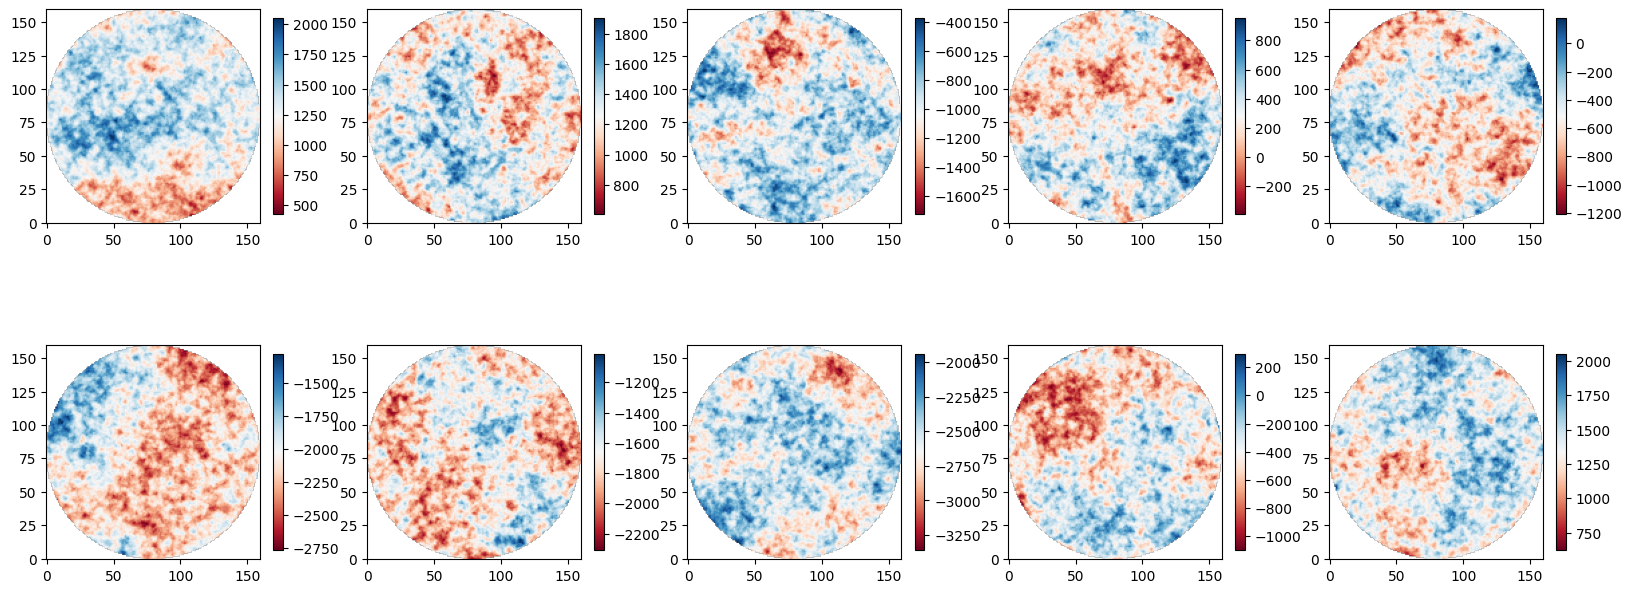

In [ ]:
phs = fits.getdata(os.path.join(root_dir,'phasescreens','phase_cube.fits'))
amp = phs[0,0,:,:].copy()
phs = phs[:,1,:,:]

plt.figure(figsize=(20,8))
for j in range(10):
    plt.subplot(2,5,1+j)
    plt.imshow(np.ma.masked_array(phs[j],mask=1-amp),cmap='RdBu',origin='lower')
    plt.colorbar(shrink=0.7)